# 1.基于TauDEM的流域基础数据生产

cd C:\TauDEM\test && mpiexec -n 16 PitRemove [shuju].tif && mpiexec -n 16 pitremove -z [shuju].tif -fel [shuju]fel.tif && mpiexec -n 16 D8Flowdir -p [shuju]p.tif -sd8 [shuju]sd8.tif -fel [shuju]fel.tif && mpiexec -n 16 DinfFlowdir -ang [shuju]ang.tif -slp [shuju]slp.tif -fel [shuju]fel.tif && mpiexec -n 16 AreaD8 -p [shuju]p.tif -ad8 [shuju]ad8.tif && mpiexec -n 16 AreaDinf -ang [shuju]ang.tif -sca [shuju]sca.tif && mpiexec -n 16 Aread8 -p [shuju]p.tif -ad8 [shuju]ad8o.tif && mpiexec -n 16 Gridnet -p [shuju]p.tif -plen [shuju]plen.tif -tlen [shuju]tlen.tif -gord [shuju]gord.tif && mpiexec -n 16 PeukerDouglas -fel [shuju]fel.tif -ss [shuju]ss.tif &&  mpiexec -n 16 Aread8 -p [shuju]p.tif -ad8 [shuju]ssa.tif -wg [shuju]ss.tif && mpiexec -n 16 Threshold -ssa [shuju]ssa.tif -src [shuju]src.tif -thresh 300 && mpiexec -n 16 Streamnet -fel [shuju]fel.tif -p [shuju]p.tif -ad8 [shuju]ad8.tif -src [shuju]src.tif -ord [shuju]rd3.tif -tree [shuju]tree.dat -coord [shuju]coord.dat -net [shuju]net.shp -w [shuju]w.tif

# 2.算法设计

## 1.流域基本信息

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

from shapely.geometry import Point,LineString,Polygon,MultiPoint

In [2]:
#data1用于存储河流数据 有河流上下游拓扑结构信息
#data2用于存储子流域数据 无河流上下游拓扑结构信息
#datarh用于存储data2融合细小斑块后的数据
#原始子流域无上下游拓扑关系信息，datafile用于存储data1，data2空间连接后，拥有上下游关系的子流域数据

In [3]:
data1 = gpd.GeoDataFrame.from_file(r'C:\Users\SLL\Desktop\test\test\n35e100_demnet.shp')#读取河网数据

In [4]:
data2 = gpd.GeoDataFrame.from_file(r'C:\Users\SLL\Desktop\test\test\面数据\n35e100_demw.shp')#读取子流域数据

In [5]:
# crs       # 查看坐标参考系
# set_crs() # 设置坐标参考系，类似于ArcGIS 定义投影
# to_crs()  # 转换坐标参考系，类似于ArcGIS 投影

In [6]:
data1.crs #data1坐标信息

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [7]:
data1 #查看数据属性格式 共有10609条数据

,LINKNO,DSLINKNO,USLINKNO1,USLINKNO2,DSNODEID,strmOrder,Length,Magnitude,DSContArea,strmDrop,Slope,StraightL,USContArea,WSNO,DOUTEND,DOUTSTART,DOUTMID,geometry
0,7968,-1,7952,7696,-1,5,584.4,75,3.295292e+09,0.00,0.000000,509.8,3.294985e+09,7968,0.0,584.4,292.2,"LINESTRING (102.13250 39.75750, 102.13333 39.7..."
1,7952,7968,7936,129,-1,4,10687.7,45,1.834803e+09,1.92,0.000179,6278.0,1.807077e+09,7952,584.4,11272.2,5928.3,"LINESTRING (102.13500 39.75333, 102.13583 39.7..."
2,7936,7952,11169,785,-1,4,3004.1,44,1.766348e+09,4.40,0.001464,2725.3,1.758176e+09,7936,11272.2,14276.3,12774.2,"LINESTRING (102.19167 39.71750, 102.19083 39.7..."
3,11169,7936,11153,2097,-1,4,16733.7,43,1.705383e+09,10.67,0.000638,11961.5,1.646143e+09,11169,14276.3,31010.1,22643.2,"LINESTRING (102.16833 39.70083, 102.16750 39.7..."
4,7920,-1,7904,7328,-1,4,1042.1,79,2.818808e+09,0.00,0.000000,1020.3,2.817452e+09,7920,0.0,1042.1,521.1,"LINESTRING (101.29000 39.74750, 101.29000 39.7..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10604,191,-1,-1,-1,-1,1,8207.9,1,3.858244e+07,332.93,0.040562,7285.1,1.273814e+07,191,0.0,8207.9,4103.9,"LINESTRING (100.45250 35.24083, 100.45167 35.2..."
10605,127,7055,-1,-1,-1,1,1237.4,1,1.193391e+07,8.44,0.006820,878.6,1.131370e+07,127,69676.9,70914.3,70295.6,"LINESTRING (101.11583 35.30667, 101.11667 35.3..."
10606,79,7279,-1,-1,-1,1,5358.7,1,1.965585e+07,51.82,0.009670,4021.6,1.711367e+07,79,18536.2,23894.9,21215.5,"LINESTRING (100.72750 35.27333, 100.72750 35.2..."
10607,31,5967,-1,-1,-1,1,10608.1,1,4.849897e+07,185.35,0.017473,9631.7,1.059126e+07,31,20937.9,31546.1,26242.0,"LINESTRING (104.43750 35.23667, 104.43750 35.2..."


In [8]:
data2.crs #data2坐标信息

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [9]:
data2 #查看数据属性格式 共有15601条数据

,Id,gridcode,geometry
0,1,6256,"POLYGON ((103.05208 39.99542, 103.05107 39.995..."
1,2,80,"POLYGON ((100.49208 39.99292, 100.49316 39.994..."
2,3,288,"POLYGON ((103.17875 39.98708, 103.17958 39.987..."
3,4,5616,"POLYGON ((100.35125 39.98625, 100.35097 39.986..."
4,5,5360,"POLYGON ((103.33625 39.98208, 103.33337 39.983..."
...,...,...,...
15596,15597,5727,"POLYGON ((101.36708 35.01958, 101.36742 35.020..."
15597,15598,5023,"POLYGON ((102.58375 35.04292, 102.58318 35.052..."
15598,15599,3439,"POLYGON ((103.49125 35.07792, 103.49047 35.078..."
15599,15600,3951,"POLYGON ((103.58792 35.03042, 103.58753 35.031..."


<AxesSubplot:>

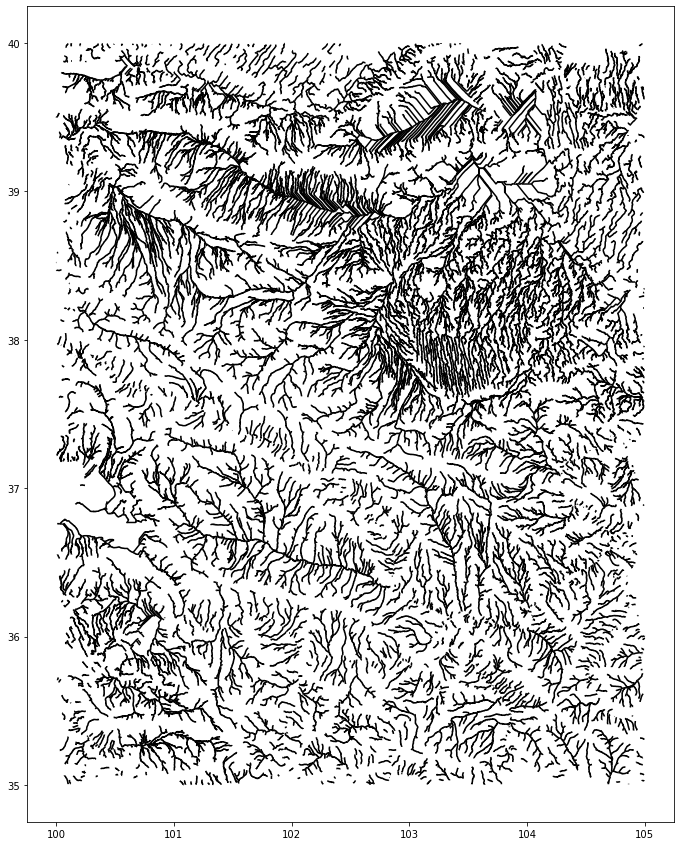

In [10]:
data1.plot(figsize=(15,15),edgecolor='k')

<AxesSubplot:>

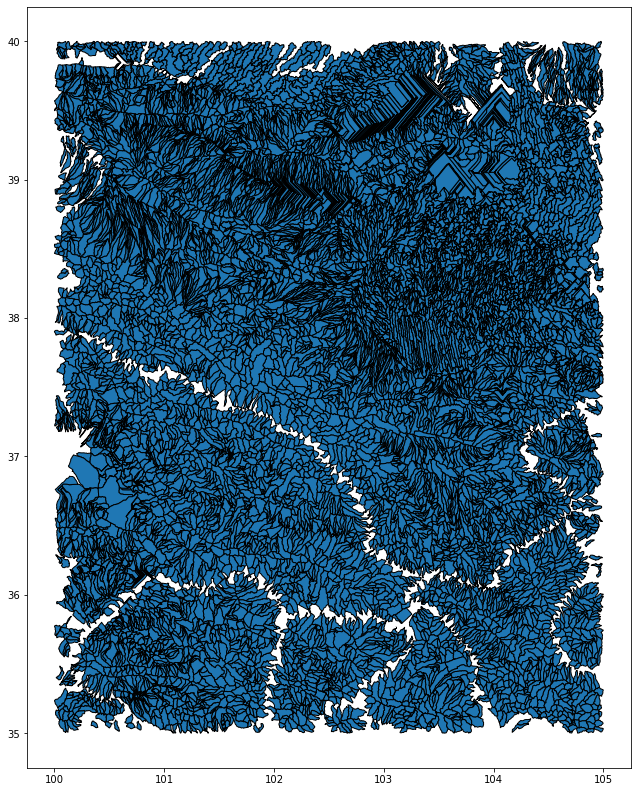

In [11]:
data2.plot(figsize=(14,14),edgecolor='k')

## 2.空间融合
由于存在相同的代码，多为细小斑块，使用空间融合将部分细小斑块与相同编号的版块进行合并。
融合 dissolve()：有时候我们希望对矢量数据按照某些字段进行分组，再分别对非矢量列与矢量列进行聚合及合并。

In [12]:
import geopandas
dir(geopandas) #查看geopandas功能

['GeoDataFrame',
 'GeoSeries',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_compat',
 '_config',
 '_decorator',
 '_vectorized',
 '_version',
 'array',
 'base',
 'clip',
 'datasets',
 'explore',
 'geodataframe',
 'geopandas',
 'geoseries',
 'gpd',
 'io',
 'np',
 'options',
 'overlay',
 'pd',
 'plotting',
 'points_from_xy',
 'read_feather',
 'read_file',
 'read_parquet',
 'read_postgis',
 'show_versions',
 'sindex',
 'sjoin',
 'sjoin_nearest',
 'tools']

In [13]:
help(geopandas)

Help on package geopandas:

NAME
    geopandas

PACKAGE CONTENTS
    _compat
    _config
    _decorator
    _vectorized
    _version
    array
    base
    conftest
    datasets (package)
    explore
    geodataframe
    geoseries
    io (package)
    plotting
    sindex
    testing
    tests (package)
    tools (package)

DATA
    options = Options(
      display_precision: None [default: Non...USE_PYGEO...

VERSION
    0.10.2

FILE
    d:\000computersofeware\000installsoftware\002subject\anaconda3\lib\site-packages\geopandas\__init__.py




In [14]:
data2.head()

,Id,gridcode,geometry
0,1,6256,"POLYGON ((103.05208 39.99542, 103.05107 39.995..."
1,2,80,"POLYGON ((100.49208 39.99292, 100.49316 39.994..."
2,3,288,"POLYGON ((103.17875 39.98708, 103.17958 39.987..."
3,4,5616,"POLYGON ((100.35125 39.98625, 100.35097 39.986..."
4,5,5360,"POLYGON ((103.33625 39.98208, 103.33337 39.983..."


In [15]:
datarh = data2.dissolve(by='gridcode',aggfunc='sum')# 按照代码融合（合并）斑块

In [16]:
len(datarh)

10588

In [17]:
print(datarh) #融合后，减少了5000个细小斑块

                                                   geometry     Id
gridcode                                                          
0         POLYGON ((103.28792 39.94125, 103.28389 39.941...     34
1         POLYGON ((100.52792 39.70625, 100.53019 39.705...    775
2         POLYGON ((101.41125 39.28625, 101.40882 39.287...   2804
3         POLYGON ((102.94708 39.00208, 102.94458 39.002...   4071
4         POLYGON ((103.61625 38.69125, 103.61579 38.691...   5784
...                                                     ...    ...
13669     MULTIPOLYGON (((102.85233 38.34799, 102.85278 ...  13790
13685     POLYGON ((104.31292 38.32792, 104.31330 38.331...   7010
13701     MULTIPOLYGON (((102.90497 38.37580, 102.88618 ...  12707
13717     MULTIPOLYGON (((104.34685 38.38000, 104.34792 ...  13774
13733     POLYGON ((104.31875 38.41292, 104.31784 38.413...   6712

[10588 rows x 2 columns]


In [18]:
datarh = datarh.reset_index()
datarh 

,gridcode,geometry,Id
0,0,"POLYGON ((103.28792 39.94125, 103.28389 39.941...",34
1,1,"POLYGON ((100.52792 39.70625, 100.53019 39.705...",775
2,2,"POLYGON ((101.41125 39.28625, 101.40882 39.287...",2804
3,3,"POLYGON ((102.94708 39.00208, 102.94458 39.002...",4071
4,4,"POLYGON ((103.61625 38.69125, 103.61579 38.691...",5784
...,...,...,...
10583,13669,"MULTIPOLYGON (((102.85233 38.34799, 102.85278 ...",13790
10584,13685,"POLYGON ((104.31292 38.32792, 104.31330 38.331...",7010
10585,13701,"MULTIPOLYGON (((102.90497 38.37580, 102.88618 ...",12707
10586,13717,"MULTIPOLYGON (((104.34685 38.38000, 104.34792 ...",13774


## 2.# 空间连接与属性连接

sjoin()函数

In [26]:
help(geopandas.sjoin_nearest)

Help on function sjoin_nearest in module geopandas.tools.sjoin:

sjoin_nearest(left_df: geopandas.geodataframe.GeoDataFrame, right_df: geopandas.geodataframe.GeoDataFrame, how: str = 'inner', max_distance: Optional[float] = None, lsuffix: str = 'left', rsuffix: str = 'right', distance_col: Optional[str] = None) -> geopandas.geodataframe.GeoDataFrame
    Spatial join of two GeoDataFrames based on the distance between their geometries.
    
    Results will include multiple output records for a single input record
    where there are multiple equidistant nearest or intersected neighbors.
    
    See the User Guide page
    https://geopandas.readthedocs.io/en/latest/docs/user_guide/mergingdata.html
    for more details.
    
    
    Parameters
    ----------
    left_df, right_df : GeoDataFrames
    how : string, default 'inner'
        The type of join:
    
        * 'left': use keys from left_df; retain only left_df geometry column
        * 'right': use keys from right_df; retain on

###### sjoin函数使用方法
left_df：GeoDataFrame，传入空间连接对应的左表

right_df：GeoDataFrame，传入空间连接对应的右表

how：字符型，用于决定连接方式，'inner'表示内连接，且连接结果表中的矢量列来自左表；'left'表示左连接，且结果表中的矢量列来自左表；'right'表示右连接，最终结果表中的矢量列来自右表

op：字符型，用于设定拓扑判断的规则，'intersects'代表相交，即几何对象之间存在共有的边或内部点；'contains'代表包含，即一个几何对象至少有一个点位于另一个几何对象内部，且其本身没有任何点落在另一个结几何对象的外部；'within'表示在内部，是'contains'的相反情况，即左表被右表矢量'contains'

lsuffix：字符型，代表当左右表连接之后存在重名列时，为左表重名的列添加的后缀，默认为'left'

rsuffix：字符型，意义类似lsuffix，默认为'right

In [20]:
datafile =gpd.sjoin(datarh,data1,how='right',op='contains') #使用sjoin函数进行连接 目标数据在前，连接数据在后

D:\000computersofeware\000installsoftware\002subject\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3364: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if (await self.run_code(code, result,  async_=asy)):


In [21]:
datafile

,index_left,gridcode,Id,LINKNO,DSLINKNO,USLINKNO1,USLINKNO2,DSNODEID,strmOrder,Length,...,DSContArea,strmDrop,Slope,StraightL,USContArea,WSNO,DOUTEND,DOUTSTART,DOUTMID,geometry
0,NaN,NaN,NaN,7968,-1,7952,7696,-1,5,584.4,...,3.295292e+09,0.00,0.000000,509.8,3.294985e+09,7968,0.0,584.4,292.2,"LINESTRING (102.13250 39.75750, 102.13333 39.7..."
1,NaN,NaN,NaN,7952,7968,7936,129,-1,4,10687.7,...,1.834803e+09,1.92,0.000179,6278.0,1.807077e+09,7952,584.4,11272.2,5928.3,"LINESTRING (102.13500 39.75333, 102.13583 39.7..."
2,NaN,NaN,NaN,7936,7952,11169,785,-1,4,3004.1,...,1.766348e+09,4.40,0.001464,2725.3,1.758176e+09,7936,11272.2,14276.3,12774.2,"LINESTRING (102.19167 39.71750, 102.19083 39.7..."
3,NaN,NaN,NaN,11169,7936,11153,2097,-1,4,16733.7,...,1.705383e+09,10.67,0.000638,11961.5,1.646143e+09,11169,14276.3,31010.1,22643.2,"LINESTRING (102.16833 39.70083, 102.16750 39.7..."
4,7911.0,7920.0,485.0,7920,-1,7904,7328,-1,4,1042.1,...,2.818808e+09,0.00,0.000000,1020.3,2.817452e+09,7920,0.0,1042.1,521.1,"LINESTRING (101.29000 39.74750, 101.29000 39.7..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10604,191.0,191.0,15123.0,191,-1,-1,-1,-1,1,8207.9,...,3.858244e+07,332.93,0.040562,7285.1,1.273814e+07,191,0.0,8207.9,4103.9,"LINESTRING (100.45250 35.24083, 100.45167 35.2..."
10605,NaN,NaN,NaN,127,7055,-1,-1,-1,1,1237.4,...,1.193391e+07,8.44,0.006820,878.6,1.131370e+07,127,69676.9,70914.3,70295.6,"LINESTRING (101.11583 35.30667, 101.11667 35.3..."
10606,NaN,NaN,NaN,79,7279,-1,-1,-1,1,5358.7,...,1.965585e+07,51.82,0.009670,4021.6,1.711367e+07,79,18536.2,23894.9,21215.5,"LINESTRING (100.72750 35.27333, 100.72750 35.2..."
10607,NaN,NaN,NaN,31,5967,-1,-1,-1,1,10608.1,...,4.849897e+07,185.35,0.017473,9631.7,1.059126e+07,31,20937.9,31546.1,26242.0,"LINESTRING (104.43750 35.23667, 104.43750 35.2..."


<AxesSubplot:>

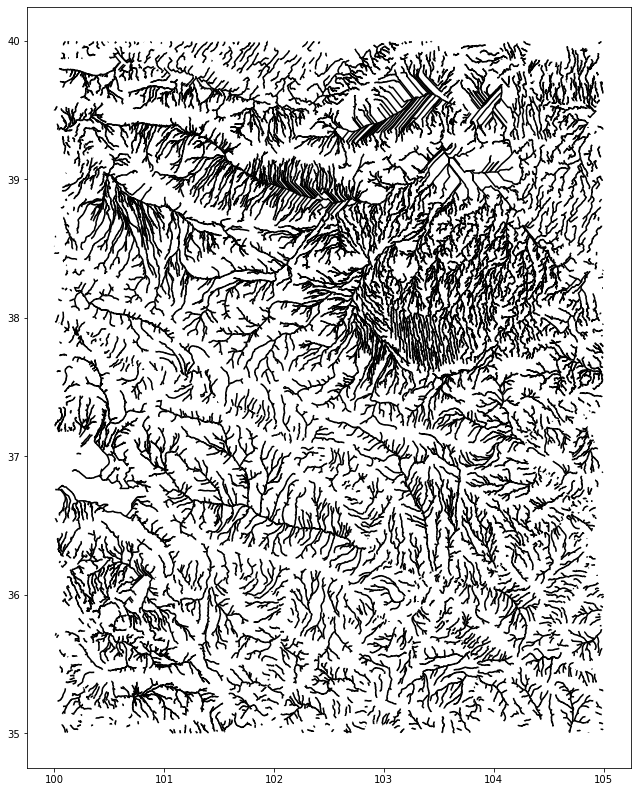

In [22]:
datafile.plot(figsize=(14,14),edgecolor='k')

In [23]:
print(datafile)

       index_left  gridcode       Id  LINKNO  DSLINKNO  USLINKNO1  USLINKNO2  \
0             NaN       NaN      NaN    7968        -1       7952       7696   
1             NaN       NaN      NaN    7952      7968       7936        129   
2             NaN       NaN      NaN    7936      7952      11169        785   
3             NaN       NaN      NaN   11169      7936      11153       2097   
4          7911.0    7920.0    485.0    7920        -1       7904       7328   
...           ...       ...      ...     ...       ...        ...        ...   
10604       191.0     191.0  15123.0     191        -1         -1         -1   
10605         NaN       NaN      NaN     127      7055         -1         -1   
10606         NaN       NaN      NaN      79      7279         -1         -1   
10607         NaN       NaN      NaN      31      5967         -1         -1   
10608         NaN       NaN      NaN      15      7839         -1         -1   

       DSNODEID  strmOrder   Length  ..

In [24]:
datafile.to_file(r'C:\Users\SLL\Desktop\test\datafile.shp') #导出数据

In [25]:
#子流域合并算法设计
for LINKNO in datafile['LINKNO']: 
    for DSLINKNO in datafile['DSLINKNO']:
        for USLINKNO1 in datafile['USLINKNO1']:
            for USLINKNO2 in datafile['USLINKNO2']:
                merge = set() #定义一个空集合，用于存储合并信息
                if LINKNO == DSLINKNO or LINKNO == USLINKNO1 or LINKNO == USLINKNO2:
                    merge = [i for i in range(1,len(datafile))]
                    datafile.dissolve(by='merge') # 按照相同merge字段进行融合
                    pass

                    
                    
#如何将设定的merge集合创建到SHP数据里变成一个字段；
#如何让其识别到相同流域后，立刻合并再重新遍历。                    

KeyError: 'merge'